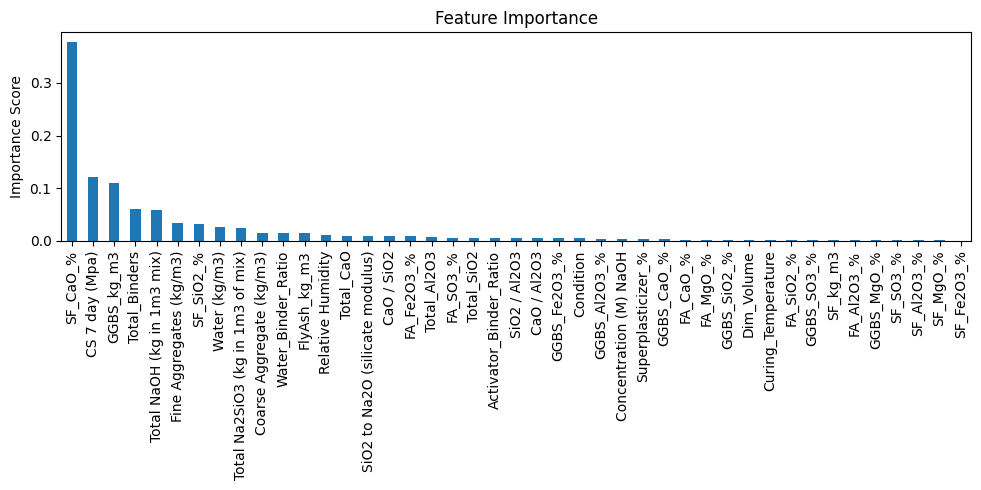

In [2]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/Users/manjilnepal/Downloads/Capstone-Final/data/final_engineered_ds.csv')
X = df.drop("CS 28 day (Mpa)", axis=1)
y = df['CS 28 day (Mpa)']

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

# Feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,5))
importance.plot(kind='bar')
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Linear Regression

In [15]:
df = pd.read_csv('/Users/manjilnepal/Downloads/Capstone-Final/data/final_engineered_ds.csv')
print(df.shape)
df.head()

(445, 44)


,GGBS_kg_m3,GGBS_CaO_%,GGBS_SiO2_%,GGBS_Al2O3_%,GGBS_MgO_%,GGBS_Fe2O3_%,GGBS_SO3_%,FlyAsh_kg_m3,FA_CaO_%,FA_SiO2_%,...,CS 7 day (Mpa),CS 28 day (Mpa),Total_Binders,Total_SiO2,Total_CaO,Total_Al2O3,SiO2 / Al2O3,CaO / Al2O3,CaO / SiO2,Dim_Volume
0,0.0,47.75,27.17,8.6,3.89,0.42,1.45,650.0,15.48,48.43,...,34.0,29.00,650.0,48.43,15.480,17.150,2.823907,2.823907,0.319637,3375000.0
1,650.0,47.75,27.17,8.6,3.89,0.42,1.45,0.0,15.48,48.43,...,34.0,40.00,650.0,27.17,47.750,8.600,3.159302,3.159302,1.757453,3375000.0
2,325.0,47.75,27.17,8.6,3.89,0.42,1.45,325.0,15.48,48.43,...,34.0,45.00,650.0,37.80,31.615,12.875,2.935922,2.935922,0.836376,3375000.0
3,0.0,47.75,27.17,8.6,3.89,0.42,1.45,637.0,15.48,48.43,...,34.0,48.00,637.0,48.43,15.480,17.150,2.823907,2.823907,0.319637,3375000.0
4,637.0,47.75,27.17,8.6,3.89,0.42,1.45,0.0,15.48,48.43,...,34.0,50.32,637.0,27.17,47.750,8.600,3.159302,3.159302,1.757453,3375000.0


In [16]:
(df.isnull().mean())*100

GGBS_kg_m3                          0.0
GGBS_CaO_%                          0.0
GGBS_SiO2_%                         0.0
GGBS_Al2O3_%                        0.0
GGBS_MgO_%                          0.0
GGBS_Fe2O3_%                        0.0
GGBS_SO3_%                          0.0
FlyAsh_kg_m3                        0.0
FA_CaO_%                            0.0
FA_SiO2_%                           0.0
FA_Al2O3_%                          0.0
FA_MgO_%                            0.0
FA_Fe2O3_%                          0.0
FA_SO3_%                            0.0
SF_kg_m3                            0.0
SF_CaO_%                            0.0
SF_SiO2_%                           0.0
SF_Al2O3_%                          0.0
SF_MgO_%                            0.0
SF_Fe2O3_%                          0.0
SF_SO3_%                            0.0
Total NaOH (kg in 1m3 mix)          0.0
Concentration (M) NaOH              0.0
Total Na2SiO3 (kg in 1m3 of mix)    0.0
Coarse Aggregate (kg/m3)            0.0


In [17]:
X = df.drop("CS 28 day (Mpa)", axis=1)
y = df['CS 28 day (Mpa)']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error
print(" R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

 R2: 0.6907706087814756
RMSE: 17.9597309765687


## Random Forest

In [4]:
df = pd.read_csv('/Users/manjilnepal/Downloads/Capstone-Final/data/final_engineered_ds.csv')
X = df.drop("CS 28 day (Mpa)", axis=1)
y = df['CS 28 day (Mpa)']


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

In [5]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    max_features='sqrt',
    
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest R2: 0.8776965775376706
Random Forest RMSE: 11.294805310852029


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Parameter grid
param_grid = {
    "n_estimators": [50, 100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring="r2"
)

grid.fit(X_train, y_train)

# Best model
best_rf = grid.best_estimator_

# Prediction
y_pred_rf = best_rf.predict(X_test)

# Evaluation
print("Best Params:", grid.best_params_)
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Best Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Random Forest R2: 0.8776965775376706
Random Forest RMSE: 11.294805310852029


In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    max_features='sqrt',
    
)

# K-Fold setup
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross validation (R2)
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=kfold,
    scoring="r2",
    n_jobs=-1
)

print("CV Scores:", cv_scores)
print("Mean CV R2:", np.mean(cv_scores))
print("Std CV:", np.std(cv_scores))

CV Scores: [0.86678129 0.74643986 0.76698559 0.89444477 0.75008409]
Mean CV R2: 0.8049471212221508
Std CV: 0.06278124349167528


In [22]:
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

In [4]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
print("XGBoost R2:", r2_score(y_test, y_pred_xgb))
print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

XGBoost R2: 0.9109112564588094
XGBoost RMSE: 9.63986298625583


In [12]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Model
xgb = XGBRegressor(random_state=42)

# Parameter grid
param_grid = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# Grid search
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

# Best model
best_xgb = grid.best_estimator_

# Prediction
y_pred = best_xgb.predict(X_test)

# Evaluation
print("Best Params:", grid.best_params_)
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.8}
R2: 0.9038565911436117
RMSE: 10.014267832061197
